## Auto-Regressive (AR) Model:

### AR(p) Autoregressive Model:
In a moving average model as we saw with Holt-Winters, we forecast the variable of interest using a linear combination of predictors. In our example we forecasted numbers of airline passengers in thousands based on a set of level, trend and seasonal predictors.

In an autoregression model, we forecast using a linear combination of <em>past values</em> of the variable. The term <em>autoregression</em> describes a regression of the variable against itself. An autoregression is run against a set of <em>lagged values</em> of order $p$.

### $y_{t} = c + \phi_{1}y_{t-1} + \phi_{2}y_{t-2} + \dots + \phi_{p}y_{t-p} + \varepsilon_{t}$

where $c$ is a constant, $\phi_{1}$ and $\phi_{2}$ are lag coefficients up to order $p$, and $\varepsilon_{t}$ is white noise.

For example, an <strong>AR(1)</strong> model would follow the formula

&nbsp;&nbsp;&nbsp;&nbsp;$y_{t} = c + \phi_{1}y_{t-1} + \varepsilon_{t}$

whereas an <strong>AR(2)</strong> model would follow the formula

&nbsp;&nbsp;&nbsp;&nbsp;$y_{t} = c + \phi_{1}y_{t-1} + \phi_{2}y_{t-2} + \varepsilon_{t}$

and so on.

Note that the lag coeffients are usually less than one, as we usually restrict autoregressive models to stationary data.<br>
Specifically, for an <strong>AR(1)</strong> model: $-1 \lt \phi_1 \lt 1$<br>
and for an <strong>AR(2)</strong> model: $-1 \lt \phi_2 \lt 1, \ \phi_1 + \phi_2 \lt 1, \ \phi_2 - \phi_1 \lt 1$<br>

Models <strong>AR(3)</strong> and higher become mathematically very complex. Fortunately statsmodels does all the heavy lifting for us.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.ar_model import AutoReg, ar_select_order

#### 2) Loading Data:

In [2]:
df = pd.read_csv('uspopulation.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,PopEst
DATE,
2011-01-01,311037
2011-02-01,311189
2011-03-01,311351
2011-04-01,311522
2011-05-01,311699


In [4]:
df.shape

(96, 1)

In [5]:
df.describe()

,PopEst
count,96.000000
mean,319826.760417
std,5159.523729
min,311037.000000
25%,315419.000000
50%,319919.500000
75%,324395.250000
max,328393.000000


##### Adding Index Frequency:

In [6]:
df.index.freq = 'MS'
df.index

DatetimeIndex(['2011-01-01', '2011-02-01', '2011-03-01', '2011-04-01',
               '2011-05-01', '2011-06-01', '2011-07-01', '2011-08-01',
               '2011-09-01', '2011-10-01', '2011-11-01', '2011-12-01',
               '2012-01-01', '2012-02-01', '2012-03-01', '2012-04-01',
               '2012-05-01', '2012-06-01', '2012-07-01', '2012-08-01',
               '2012-09-01', '2012-10-01', '2012-11-01', '2012-12-01',
               '2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01',
               '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01',
               '2013-09-01', '2013-10-01', '2013-11-01', '2013-12-01',
               '2014-01-01', '2014-02-01', '2014-03-01', '2014-04-01',
               '2014-05-01', '2014-06-01', '2014-07-01', '2014-08-01',
               '2014-09-01', '2014-10-01', '2014-11-01', '2014-12-01',
               '2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
      

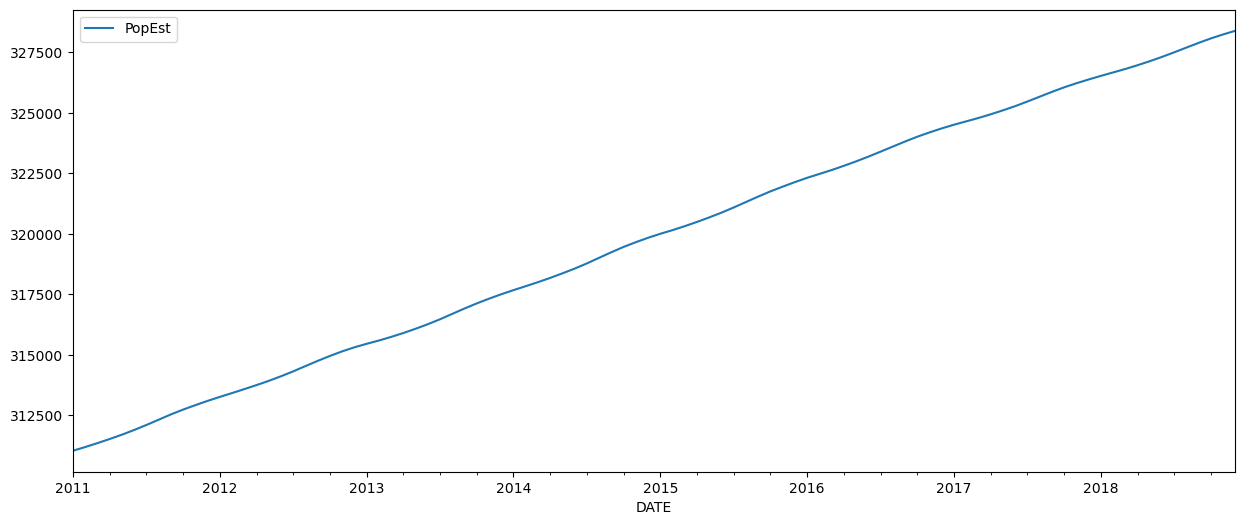

In [7]:
# Plotting Data:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) Train Test Split:

In [8]:
df.shape

(96, 1)

In [9]:
train_data = df[:84]
test_data = df[84:]
print(train_data.shape, test_data.shape)

(84, 1) (12, 1)


#### 4) Auto Regressive Model with Lag 1 [AR(1)]:

##### Model Fitting:

In [10]:
model1 = AutoReg(endog= train_data['PopEst'],
                lags= 1)

In [11]:
AR1 = model1.fit()

In [12]:
AR1.params

const        284.913797
PopEst.L1      0.999686
dtype: float64

##### Predictions:

In [13]:
# Predictions same as length of Test Data:

start = len(train_data)
end = len(test_data) + len(train_data) - 1
print(start, end)

84 95


In [14]:
preds1 = AR1.predict(start= start, end= end)

In [15]:
preds1

2018-01-01    326560.403377
2018-02-01    326742.749463
2018-03-01    326925.038278
2018-04-01    327107.269838
2018-05-01    327289.444162
2018-06-01    327471.561268
2018-07-01    327653.621173
2018-08-01    327835.623896
2018-09-01    328017.569455
2018-10-01    328199.457868
2018-11-01    328381.289152
2018-12-01    328563.063326
Freq: MS, dtype: float64

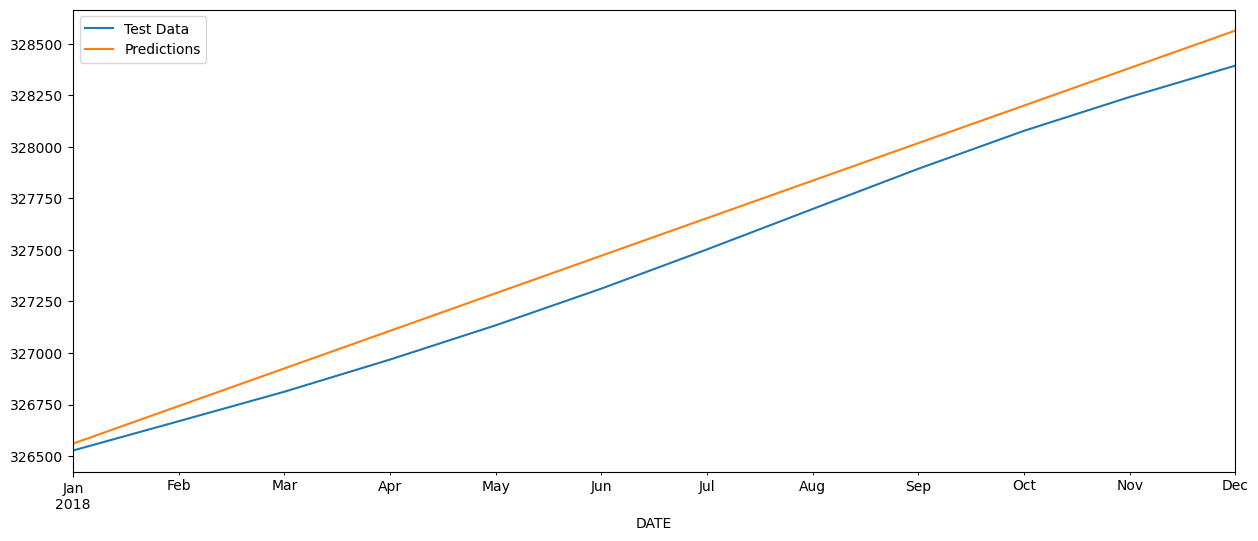

In [16]:
# Plotting Test Data with Predictions:

test_data['PopEst'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds1.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

#### 5) Auto Regressive Model with Lag 2 [AR(2)]:

84 95


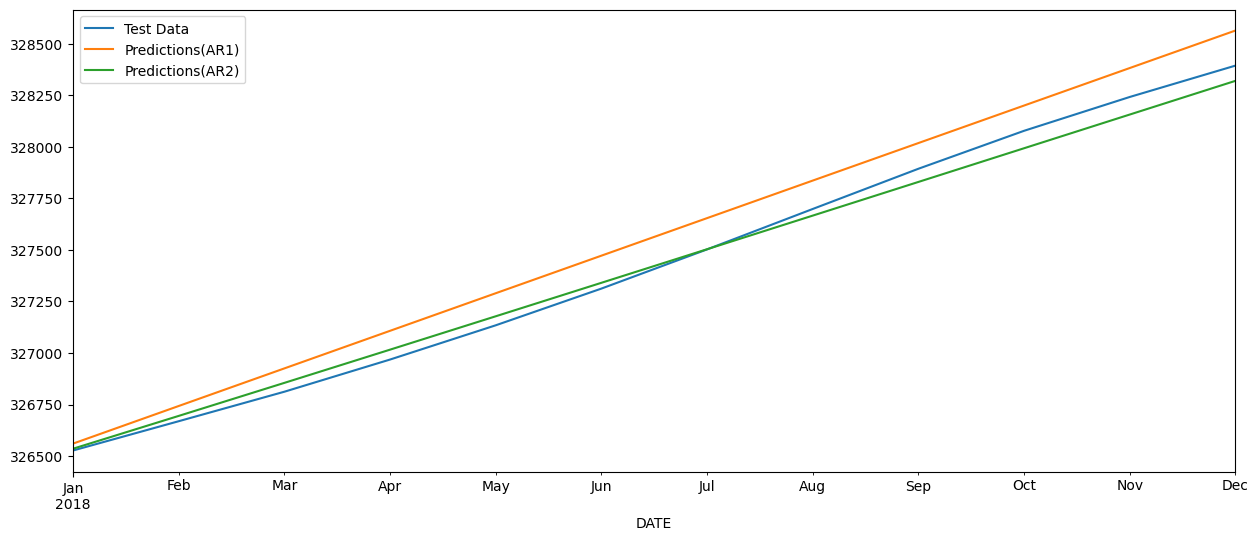

In [17]:
# Model Fitting:
model2 = AutoReg(endog= train_data['PopEst'],
                lags= 2)
AR2 = model2.fit()

# Predictions same as length of Test Data:
start = len(train_data)
end = len(test_data) + len(train_data) - 1
print(start, end)

preds2 = AR2.predict(start= start, end= end)

# Plotting Test Data with Predictions of Both Models:
test_data['PopEst'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds1.plot(kind= 'line', figsize= (15,6), label= 'Predictions(AR1)', legend= True)
preds2.plot(kind= 'line', figsize= (15,6), label= 'Predictions(AR2)', legend= True)
plt.show()

#### 6) Choosing best number of Lags:

In [18]:
lags = ar_select_order(endog= train_data['PopEst'],
                      maxlag= 10)

lags.ar_lags

[1, 2, 3, 4, 5, 6, 7, 8]

In [19]:
model = AutoReg(endog= train_data['PopEst'], 
                lags= lags.ar_lags)
AR = model.fit()

In [20]:
AR.params

const        82.309677
PopEst.L1     2.437997
PopEst.L2    -2.302100
PopEst.L3     1.565427
PopEst.L4    -1.431211
PopEst.L5     1.125022
PopEst.L6    -0.919494
PopEst.L7     0.963694
PopEst.L8    -0.439511
dtype: float64

In [21]:
# Predictions:
preds3 = AR.predict(start, end)
preds3

2018-01-01    326523.865566
2018-02-01    326662.772593
2018-03-01    326805.746921
2018-04-01    326960.064287
2018-05-01    327130.573030
2018-06-01    327315.962906
2018-07-01    327511.010252
2018-08-01    327710.938538
2018-09-01    327907.425743
2018-10-01    328092.870995
2018-11-01    328264.133911
2018-12-01    328421.667484
Freq: MS, dtype: float64

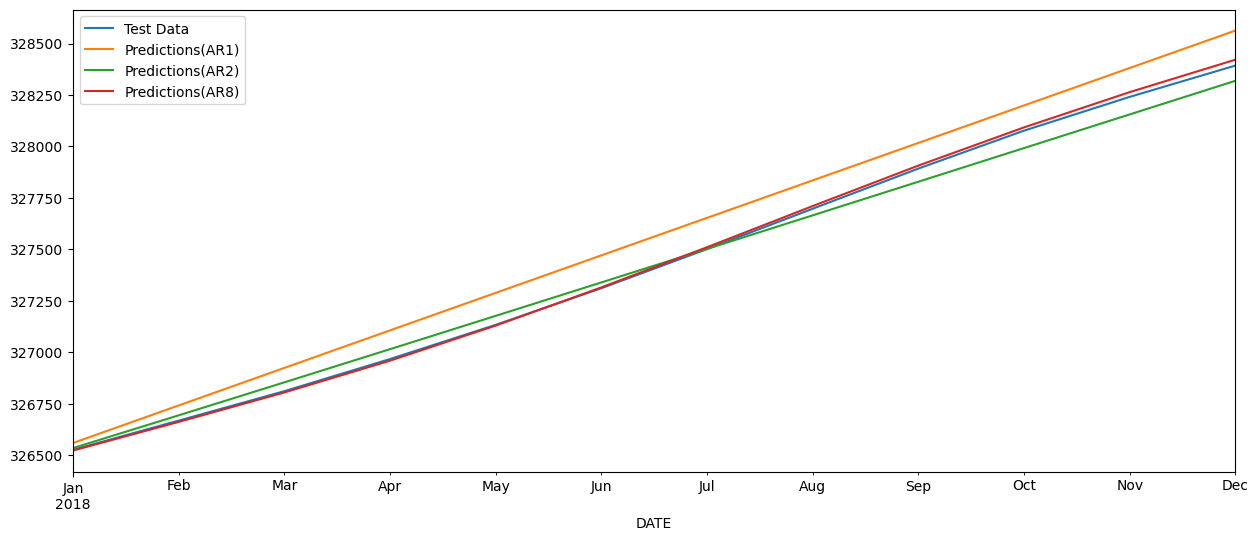

In [23]:
# Plotting Test Data and Predictions of All Models:

test_data['PopEst'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds1.plot(kind= 'line', figsize= (15,6), label= 'Predictions(AR1)', legend= True)
preds2.plot(kind= 'line', figsize= (15,6), label= 'Predictions(AR2)', legend= True)
preds3.plot(kind= 'line', figsize= (15,6), label= 'Predictions(AR8)', legend= True)
plt.show()

#### 7) Model Evaluations:

In [24]:
# Evaluation:

print(np.sqrt(mean_squared_error(test_data["PopEst"], preds1)))
print(np.sqrt(mean_squared_error(test_data["PopEst"], preds2)))
print(np.sqrt(mean_squared_error(test_data["PopEst"], preds3)))

132.09736650464217
52.08894773215732
13.673922813204326


#### 8) Forecasting:

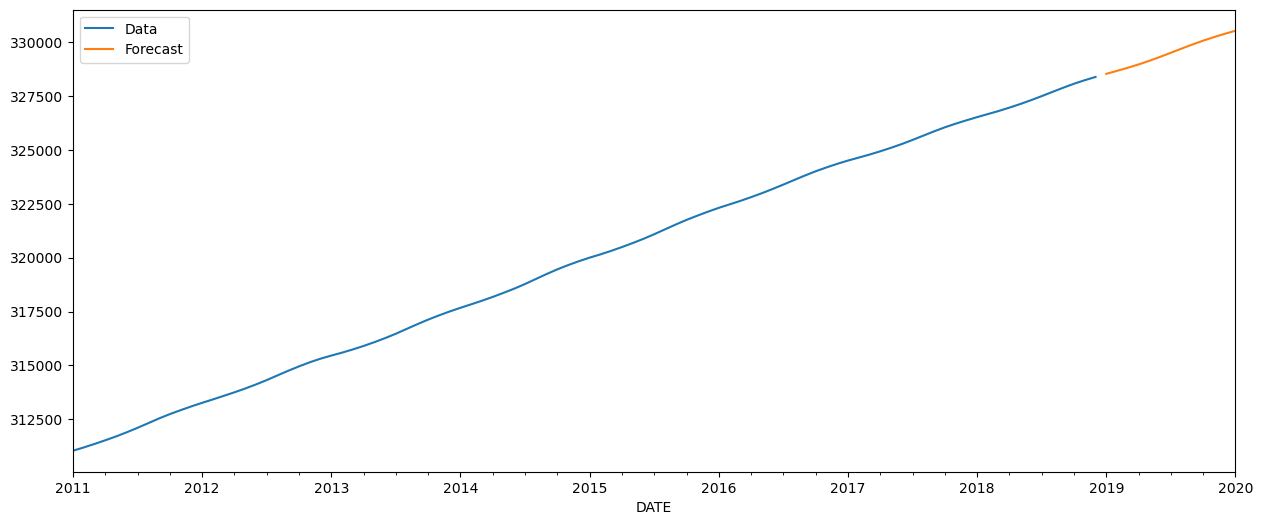

In [25]:
# Selecting Number of lags:
lags = ar_select_order(endog= df['PopEst'],
                      maxlag= 10)

# Model Fitting:
final_model = AutoReg(endog= df['PopEst'],
                     lags= lags.ar_lags)
AR = final_model.fit()

# Forecasting:
forecast = AR.predict(start= len(df), end= len(df)+12)

# Plotting Data and Forecast:
df['PopEst'].plot(kind= 'line', figsize= (15,6), label= 'Data', legend= True)
forecast.plot(kind= 'line', figsize= (15,6), label= 'Forecast', legend= True)
plt.show()